In [1]:
import sys
import os
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# Get the absolute path to the 'python' directory (one level up from 'notebooks')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)


In [2]:
from Utils.FilePaths import *
import pandas as pd

data_folder = DWD / "data_tables"

In [3]:
## Load files
files = list(Path.glob(data_folder, '*01975.csv'))
files

[PosixPath('/Users/jo/Documents/Ai_Engineering/Projects/Jo2Seb/files/data/lfs/DWD/data_tables/Hamburg-Fuhlsbüttel_01975.csv')]

In [4]:
## Load all weather data for Hamburg Fulsbüttel weather stations
df = pd.read_csv(files[0], index_col=0)
df.index = pd.to_datetime(df.index, utc=True)
df.head(5)

,precipitation,pressure_msl,sunshine,temperature,wind_direction,wind_speed,cloud_cover,dew_point,relative_humidity,visibility,wind_gust_direction,wind_gust_speed,precipitation_probability,precipitation_probability_6h,solar
datetime,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,0.3,993.8,NaN,8.2,210.0,13.0,100.0,7.8,97.0,900.0,210.0,19.8,NaN,NaN,0.0
2018-01-01 01:00:00+00:00,0.1,993.3,NaN,8.7,200.0,19.4,100.0,7.7,93.0,9000.0,220.0,38.9,NaN,NaN,0.0
2018-01-01 02:00:00+00:00,0.0,994.1,NaN,8.3,230.0,24.8,75.0,6.5,88.0,20000.0,250.0,40.7,NaN,NaN,0.0
2018-01-01 03:00:00+00:00,0.0,993.9,0.0,8.1,230.0,22.7,75.0,6.3,89.0,30000.0,200.0,37.1,NaN,NaN,0.0
2018-01-01 04:00:00+00:00,0.0,993.8,0.0,8.1,220.0,24.1,87.0,5.9,86.0,30000.0,220.0,37.1,NaN,NaN,0.0


<Axes: ylabel='datetime'>

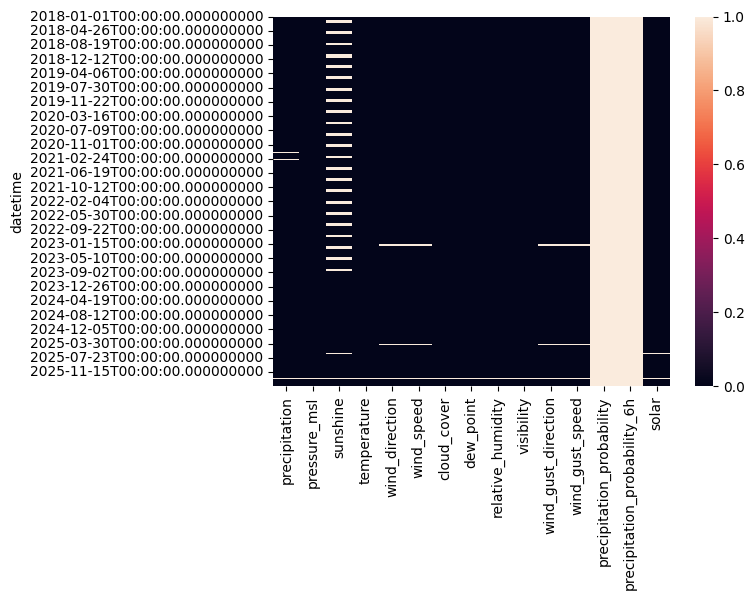

In [5]:
import seaborn as sns

mask =df.isna()
sns.heatmap(mask)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,71385.0,0.084972,0.474554,0.0,0.0,0.000,0.000,38.700
pressure_msl,71622.0,1014.882950,10.346613,974.2,1008.5,1015.500,1021.700,1048.200
sunshine,58550.0,14.554398,22.799532,0.0,0.0,0.000,28.000,60.000
temperature,71644.0,10.415553,7.281939,-13.8,5.1,10.000,15.700,38.400
wind_direction,71294.0,198.721351,89.978906,0.0,120.0,220.000,270.000,360.000
wind_speed,71175.0,14.582081,7.772548,0.0,8.6,13.700,19.400,60.100
cloud_cover,71463.0,69.852399,35.979471,0.0,37.0,87.000,100.000,100.000
dew_point,71617.0,6.390829,6.039277,-18.0,2.1,6.600,11.000,22.400
relative_humidity,71617.0,78.452253,16.445701,18.0,68.0,83.000,92.000,100.000
visibility,71463.0,30483.831073,17797.084257,40.0,15000.0,30000.000,45000.000,80000.000


In [7]:
## Missing data for wind measurements: 

            # --> Mostly direction is missing if wind speed is missing to

print("counts of no wind direction data:", len(df[df["wind_gust_direction"].isna()]))
print("counts of no wind speed data:", len(df[df["wind_gust_speed"].isna()]))
print("counts of no data for both at same time: :", len(df[df["wind_gust_speed"].isna() & df["wind_gust_direction"].isna()]))




counts of no wind direction data: 586
counts of no wind speed data: 574
counts of no data for both at same time: : 574


In [8]:
df.isna().sum()

precipitation                     363
pressure_msl                      126
sunshine                        13198
temperature                       104
wind_direction                    454
wind_speed                        573
cloud_cover                       285
dew_point                         131
relative_humidity                 131
visibility                        285
wind_gust_direction               586
wind_gust_speed                   574
precipitation_probability       71748
precipitation_probability_6h    71748
solar                             341
dtype: int64

In [9]:
# Drop columns withouth information
df =df.drop(columns= ['precipitation_probability','precipitation_probability_6h'])

# NaN are at night --> replace with 0
print("sunshine missing values: ", df["sunshine"].isna().sum())
df.loc[df["sunshine"].isna()] = 0
print("sunshine missing values after impute: ", df["sunshine"].isna().sum())

df.loc[df["wind_direction"].isna(), ["wind_direction"]] = 0
df.loc[df["wind_direction"].isna(), ["wind_direction"]] = 0


# Also interpolate missing values
#df= df.interpolate("linear")

## Select only values from 2018-2027
df = df.loc['2018':'2025', :]

sunshine missing values:  13198
sunshine missing values after impute:  0


<Axes: ylabel='datetime'>

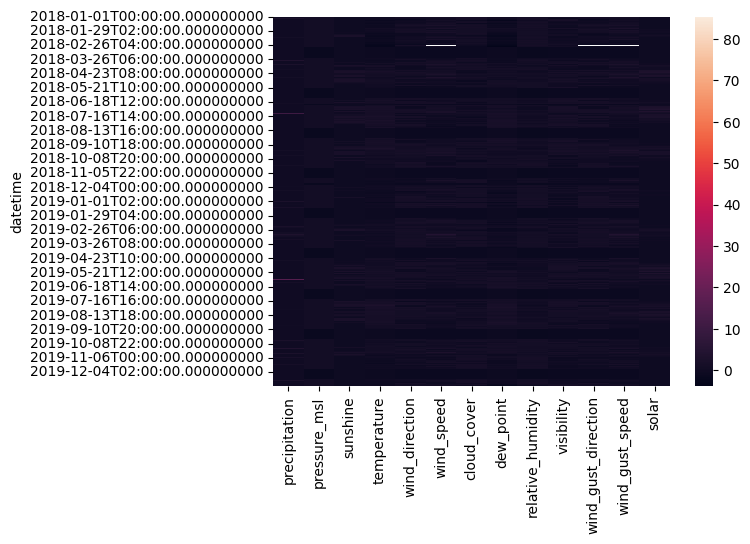

In [11]:
df_z = df.loc["2018":"2019"]
df_z = (df_z - df_z.mean()) / df_z.std()   # per column
sns.heatmap(df_z)

Text(0, 0.5, 'Wind Velocity [m/s]')

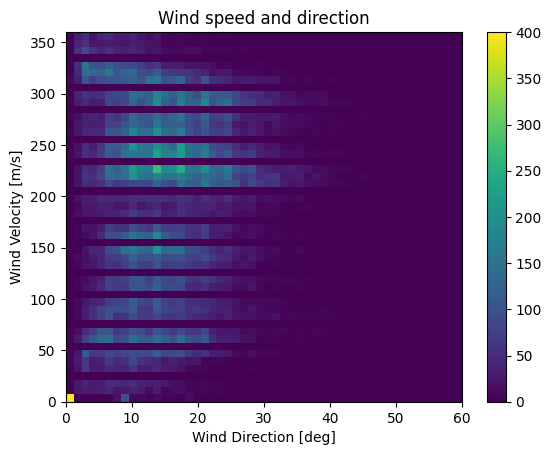

In [ ]:
plt.hist2d(df['wind_speed'], df['wind_direction'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.title("Wind speed and direction")
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

Text(0, 0.5, 'Wind Gust Velocity [m/s]')

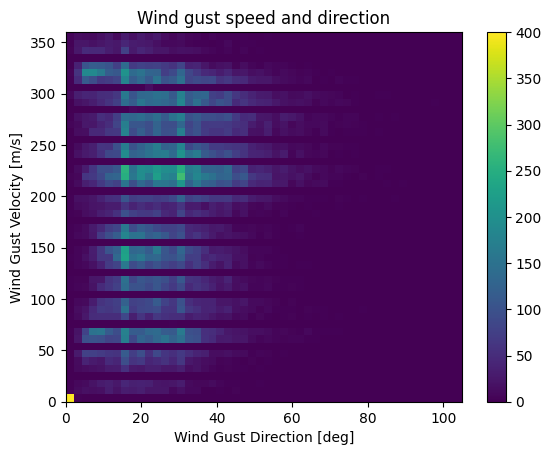

In [ ]:
plt.hist2d(df['wind_gust_speed'], df['wind_gust_direction'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.title("Wind gust speed and direction")
plt.xlabel('Wind Gust Direction [deg]')
plt.ylabel('Wind Gust Velocity [m/s]')

In [ ]:
## Convert wind speed and direction to vector

wv = df.pop('wind_speed')  # wind velocity
wgv =df.pop('wind_gust_speed') # wind gust velocity

wd_deg = df.pop("wind_direction") # wind direction
wgd_deg = df.pop("wind_gust_direction") # wind direction

wd_rad =  wd_deg * np.pi / 180 # convert degree to radians
wgd_rad = wgd_deg * np.pi / 180 

##### create vectors and add back to df

# Calculate the wind x and y components.
df['w_x'] = wv*np.cos(wd_rad)
df['w_y'] = wv*np.sin(wd_rad)

# Calculate the wind gust x and y components.
df['wg_x'] = wgv*np.cos(wgd_rad)
df['wg_y'] = wgv*np.sin(wgd_rad)

Text(0, 0.5, 'Wind vector y-component')

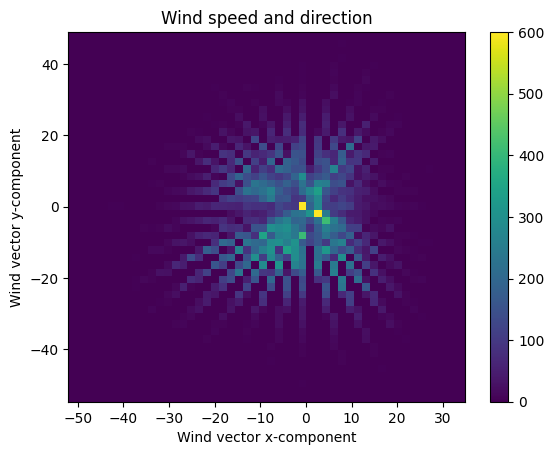

In [ ]:
plt.hist2d(df['w_x'],df['w_y'], bins=(50, 50), vmax= 600 )
plt.colorbar()
plt.title("Wind speed and direction")
plt.xlabel('Wind vector x-component')
plt.ylabel('Wind vector y-component')

Text(0, 0.5, 'Wind vector y-component')

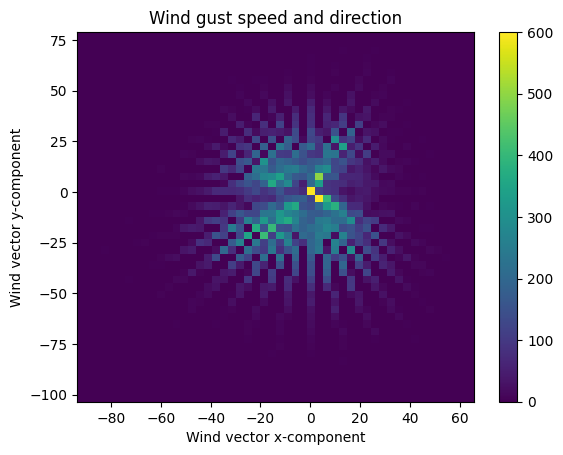

In [ ]:
plt.hist2d(df['wg_x'],df['wg_y'], bins=(50, 50), vmax= 600 )
plt.colorbar()
plt.title("Wind gust speed and direction")
plt.xlabel('Wind vector x-component')
plt.ylabel('Wind vector y-component')

In [ ]:
def plot_fourier(data_series: pd.Series, save_fig: bool = False, safe_path = pathlib.Path("")):
    
    
    fft = tf.signal.rfft(data_series)

    f_per_dataset = np.arange(0, len(fft))

    n_samples_h = len(data_series)
    hours_per_year = 24*365.2524
    years_per_dataset = n_samples_h/(hours_per_year)

    f_per_year = f_per_dataset/years_per_dataset
    
    plt.figure()
    plt.step(f_per_year, np.abs(fft))
    plt.title(data_series.name)
    plt.xscale('log')
    #plt.ylim(0, 400000)
    plt.xlim([0.1, max(plt.xlim())])
    plt.xticks([0.25, 1 ,30, 365.2524,365.2524*3 ], labels=['1/4years','1/Year', '1/month', '1/day', '1/8h'])
    _ = plt.xlabel('Frequency (log scale)')

    if not save_fig:
        plt.show()
    elif save_fig:
        file_name = data_series.name + ".pdf"
        file_path = safe_path / file_name
        plt.savefig(file_path)
        plt.close()

In [ ]:
## Plot the seasonality of all columns
safe_path = DWD / "graphs"
for col in df.columns:
    data_series = df.loc[:, col]
    plot_fourier(data_series, save_fig=True, safe_path=safe_path)

In [ ]:
df

,precipitation,pressure_msl,sunshine,temperature,cloud_cover,dew_point,relative_humidity,visibility,solar,w_x,w_y,wg_x,wg_y
datetime,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000
2018-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000
2018-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000
2018-01-01 03:00:00+00:00,0.0,993.9,0.0,8.1,75.0,6.3,89.0,30000.0,0.0,-14.591279,-17.389209,-3.486260e+01,-12.688947
2018-01-01 04:00:00+00:00,0.0,993.8,0.0,8.1,87.0,5.9,86.0,30000.0,0.0,-18.461671,-15.491181,-2.842025e+01,-23.847420
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00+00:00,0.0,1012.0,0.0,4.7,87.0,3.2,90.0,15940.0,0.0,-1.875400,-10.635924,-6.532585e+00,-17.948129
2025-12-31 20:00:00+00:00,0.0,1011.3,0.0,4.9,87.0,4.3,96.0,7270.0,0.0,-1.875400,-10.635924,-3.435134e-15,-18.700000
2025-12-31 21:00:00+00:00,0.2,1010.7,0.0,5.2,87.0,4.9,98.0,2060.0,0.0,-4.788282,-13.155697,-8.482100e+00,-23.304377


In [ ]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 70128 entries, 2018-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   precipitation      70128 non-null  float64
 1   pressure_msl       70128 non-null  float64
 2   sunshine           70128 non-null  float64
 3   temperature        70128 non-null  float64
 4   cloud_cover        70128 non-null  float64
 5   dew_point          70128 non-null  float64
 6   relative_humidity  70128 non-null  float64
 7   visibility         70128 non-null  float64
 8   solar              70128 non-null  float64
 9   w_x                70128 non-null  float64
 10  w_y                70128 non-null  float64
 11  wg_x               70128 non-null  float64
 12  wg_y               70128 non-null  float64
dtypes: float64(13)
memory usage: 7.5 MB


In [12]:
df.isna().sum()

precipitation          248
pressure_msl            66
sunshine                 0
temperature             59
wind_direction           0
wind_speed             390
cloud_cover            208
dew_point               83
relative_humidity       83
visibility             248
wind_gust_direction    385
wind_gust_speed        385
solar                   24
dtype: int64

In [13]:
file_path = DWD / "processed_data" / "Weather_hourly_cleaned-Fuhlsbüttel.csv"
df.to_csv(file_path)